# Equity Risk Forecasting Project
## Days 10–14: Portfolio Optimization, Risk Dashboard, Forecasting, and Final Model

Final stage of the risk analytics pipeline.


### Setup Cell
Run this first.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

OUTPUT_DIR = 'outputs'
FIG_DIR = 'figures'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print('Folders ready')


Folders ready


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text

OUTPUT_DIR = "outputs"
FIG_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

DB_USER = "postgres"
DB_PASS = "laleh"   # <-- change
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "equity_risk_project"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    print("DB OK:", conn.execute(text("SELECT 1")).fetchone())
print("Folders OK:", OUTPUT_DIR, FIG_DIR)

DB OK: (1,)
Folders OK: outputs figures


In [3]:
r = pd.read_sql("SELECT date, ticker, daily_return FROM returns;", engine)
w = pd.read_sql("SELECT ticker, weight FROM portfolio_weights;", engine)

r["date"] = pd.to_datetime(r["date"])
r["daily_return"] = pd.to_numeric(r["daily_return"], errors="coerce")
w["weight"] = pd.to_numeric(w["weight"], errors="coerce")

# Asset return matrix
returns_matrix = (r.pivot(index="date", columns="ticker", values="daily_return")
                    .dropna()
                    .sort_index())

# Weights vector (current portfolio)
weights = w.set_index("ticker")["weight"].reindex(returns_matrix.columns)

returns_matrix.shape, weights

((1509, 5),
 ticker
 AAPL    0.25
 JPM     0.15
 MSFT    0.25
 NVDA    0.20
 SPY     0.15
 Name: weight, dtype: float64)

In [4]:
TRADING_DAYS = 252

mu_daily = returns_matrix.mean()
cov_daily = returns_matrix.cov()

mu_annual = mu_daily * TRADING_DAYS
cov_annual = cov_daily * TRADING_DAYS

mu_annual, cov_annual.shape

(ticker
 AAPL    0.363900
 JPM     0.223266
 MSFT    0.290452
 NVDA    0.749294
 SPY     0.177744
 dtype: float64,
 (5, 5))

In [5]:
N_PORTFOLIOS = 20000
rf = 0.0  # risk-free rate (keep 0 unless you want to set e.g. 0.04)

tickers = returns_matrix.columns.tolist()
n = len(tickers)

W = np.random.dirichlet(np.ones(n), size=N_PORTFOLIOS)  # weights that sum to 1

port_returns = W @ mu_annual.values
port_vars = np.einsum("ij,jk,ik->i", W, cov_annual.values, W)
port_vols = np.sqrt(port_vars)
port_sharpes = (port_returns - rf) / port_vols

frontier = pd.DataFrame({
    "return_annual": port_returns,
    "vol_annual": port_vols,
    "sharpe": port_sharpes
})

frontier.head()

,return_annual,vol_annual,sharpe
0,0.390281,0.287288,1.358500
1,0.335922,0.259443,1.294784
2,0.337884,0.265181,1.274162
3,0.450680,0.316501,1.423948
4,0.326625,0.256576,1.273015


In [6]:
frontier.to_csv(f"{OUTPUT_DIR}/day10_efficient_frontier.csv", index=False)
print("Saved:", f"{OUTPUT_DIR}/day10_efficient_frontier.csv")

Saved: outputs/day10_efficient_frontier.csv


In [7]:
idx_min_var = np.argmin(port_vols)
idx_max_sharpe = np.argmax(port_sharpes)

min_var_w = W[idx_min_var]
max_sharpe_w = W[idx_max_sharpe]

opt_weights = pd.DataFrame({
    "ticker": tickers,
    "min_variance_weight": min_var_w,
    "max_sharpe_weight": max_sharpe_w,
})

opt_weights.to_csv(f"{OUTPUT_DIR}/day10_optimal_weights.csv", index=False)
print("Saved:", f"{OUTPUT_DIR}/day10_optimal_weights.csv")

opt_weights.sort_values("max_sharpe_weight", ascending=False).head(10)

Saved: outputs/day10_optimal_weights.csv


,ticker,min_variance_weight,max_sharpe_weight
3,NVDA,0.007724,0.515471
0,AAPL,0.018950,0.300633
1,JPM,0.043291,0.171732
2,MSFT,0.047641,0.011812
4,SPY,0.882394,0.000352


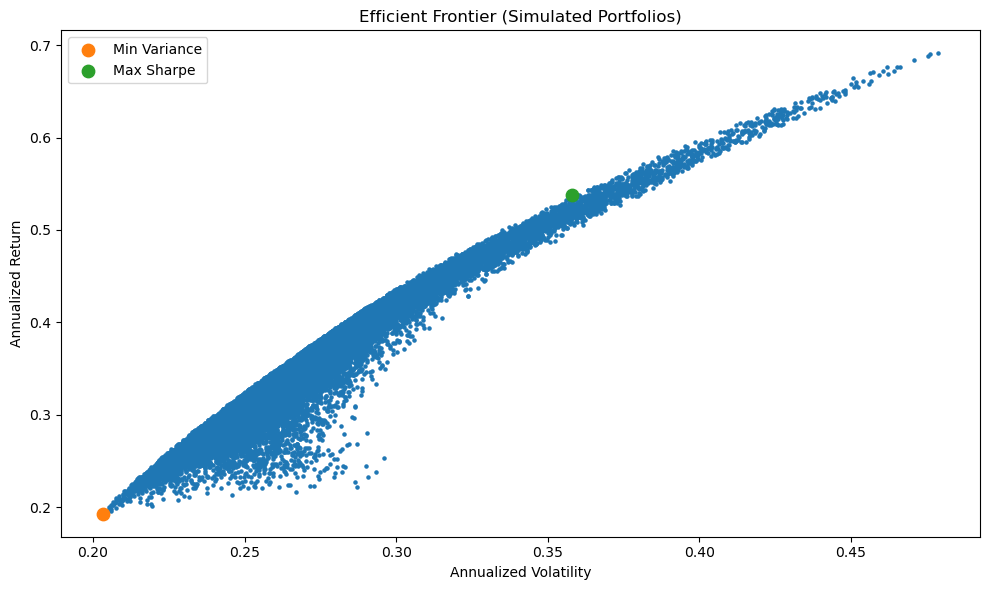

Saved: figures/day10_efficient_frontier.png


In [8]:
plt.figure(figsize=(10,6))
plt.scatter(frontier["vol_annual"], frontier["return_annual"], s=5)

# Highlight optimal points
plt.scatter(port_vols[idx_min_var], port_returns[idx_min_var], s=80, label="Min Variance")
plt.scatter(port_vols[idx_max_sharpe], port_returns[idx_max_sharpe], s=80, label="Max Sharpe")

plt.title("Efficient Frontier (Simulated Portfolios)")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/day10_efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", f"{FIG_DIR}/day10_efficient_frontier.png")

In [10]:
# Current portfolio performance
current_return = weights @ mu_annual
current_vol = np.sqrt(weights.T @ cov_annual.values @ weights)
current_sharpe = current_return / current_vol

current_return, current_vol, current_sharpe

(np.float64(0.3735980797003562),
 np.float64(0.274299763972673),
 np.float64(1.3620065664277266))

In [11]:
min_var_return = port_returns[idx_min_var]
min_var_vol = port_vols[idx_min_var]
min_var_sharpe = min_var_return / min_var_vol

max_sharpe_return = port_returns[idx_max_sharpe]
max_sharpe_vol = port_vols[idx_max_sharpe]
max_sharpe_sharpe = port_sharpes[idx_max_sharpe]

In [12]:
comparison = pd.DataFrame({
    "Portfolio": ["Current", "Min Variance", "Max Sharpe"],
    "Return": [current_return, min_var_return, max_sharpe_return],
    "Volatility": [current_vol, min_var_vol, max_sharpe_vol],
    "Sharpe": [current_sharpe, min_var_sharpe, max_sharpe_sharpe]
})

comparison

,Portfolio,Return,Volatility,Sharpe
0,Current,0.373598,0.274300,1.362007
1,Min Variance,0.193026,0.203340,0.949281
2,Max Sharpe,0.537475,0.358094,1.500933


In [13]:
comparison.to_csv(f"{OUTPUT_DIR}/day10_portfolio_comparison.csv", index=False)

print("Saved:", f"{OUTPUT_DIR}/day10_portfolio_comparison.csv")

Saved: outputs/day10_portfolio_comparison.csv


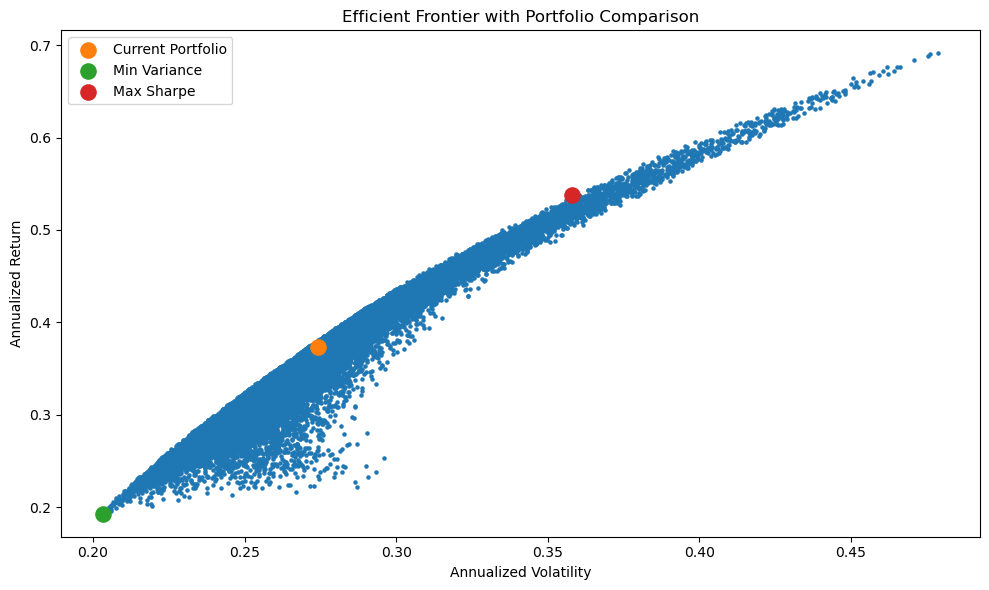

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(frontier["vol_annual"], frontier["return_annual"], s=5)

plt.scatter(current_vol, current_return, s=120, label="Current Portfolio")
plt.scatter(min_var_vol, min_var_return, s=120, label="Min Variance")
plt.scatter(max_sharpe_vol, max_sharpe_return, s=120, label="Max Sharpe")

plt.title("Efficient Frontier with Portfolio Comparison")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")

plt.legend()
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/day10_frontier_with_portfolios.png", dpi=300)

plt.show()

In [15]:
# Rebuild portfolio daily returns
r = pd.read_sql("SELECT date, ticker, daily_return FROM returns;", engine)
w = pd.read_sql("SELECT ticker, weight FROM portfolio_weights;", engine)

r["date"] = pd.to_datetime(r["date"])
df = r.merge(w, on="ticker")
df["weighted_return"] = df["daily_return"] * df["weight"]

portfolio_ts = (
    df.groupby("date", as_index=False)["weighted_return"]
      .sum()
      .rename(columns={"weighted_return": "portfolio_return"})
      .sort_values("date")
)

portfolio_ts.head()

,date,portfolio_return
0,2019-01-02,0.000000
1,2019-01-03,-0.051894
2,2019-01-04,0.045667
3,2019-01-07,0.011638
4,2019-01-08,0.002726


In [16]:
portfolio_ts.to_csv(f"{OUTPUT_DIR}/day11_portfolio_timeseries.csv", index=False)

In [17]:
asset_returns = r.copy()

asset_returns.to_csv(f"{OUTPUT_DIR}/day11_asset_returns.csv", index=False)

In [19]:
# rebuild returns_matrix and weights if needed
returns_matrix = r.pivot(index="date", columns="ticker", values="daily_return").dropna()
weights = w.set_index("ticker")["weight"]

# covariance
cov_matrix = returns_matrix.cov()

# portfolio volatility
portfolio_var = weights.T @ cov_matrix.values @ weights
portfolio_vol = np.sqrt(portfolio_var)

# asset volatilities
asset_vol = returns_matrix.std()

# diversification ratio
weighted_vol = (weights * asset_vol).sum()
diversification_ratio = weighted_vol / portfolio_vol

diversification_ratio

np.float64(1.2666613804189086)

In [20]:
risk_summary = pd.DataFrame({
    "metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Diversification Ratio"
    ],
    "value": [
        current_return,
        current_vol,
        current_sharpe,
        diversification_ratio
    ]
})

In [21]:
risk_summary.to_csv(f"{OUTPUT_DIR}/day11_risk_metrics_summary.csv", index=False)

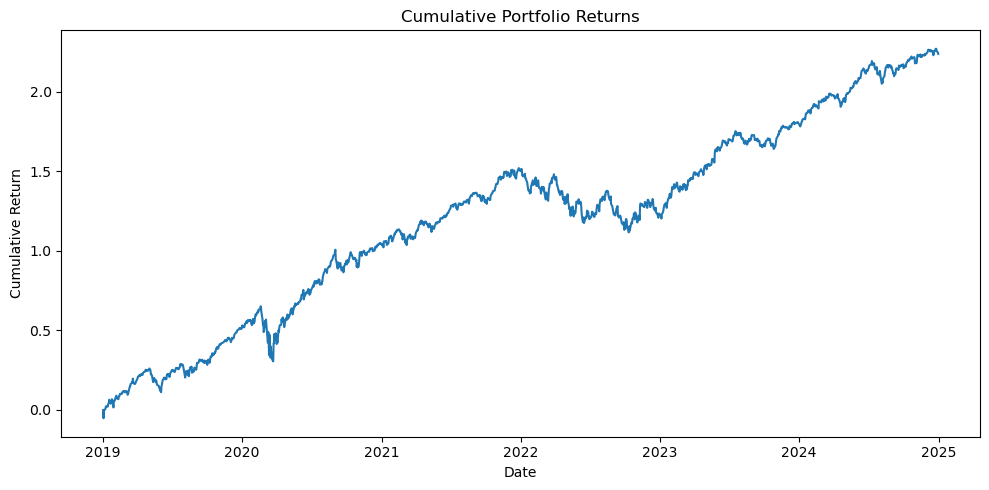

In [22]:
plt.figure(figsize=(10,5))

plt.plot(portfolio_ts["date"], portfolio_ts["portfolio_return"].cumsum())

plt.title("Cumulative Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.tight_layout()

plt.savefig(f"{FIG_DIR}/day11_cumulative_returns.png", dpi=300)

plt.show()